#Lab 5: Using a Neural Network to Fit the Data

---

## Parameter estimation

In [1]:
# Import libraries
import torch
from matplotlib import pyplot as plt

In [2]:
# The t_c values are temperatures in Celsius
# The t_u values are read from our new thermometer with unknown units

t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [32.9, 57.2, 59.0, 82.4, 51.8, 46.4, 37.4, 24.8, 42.8, 55.4, 69.8]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

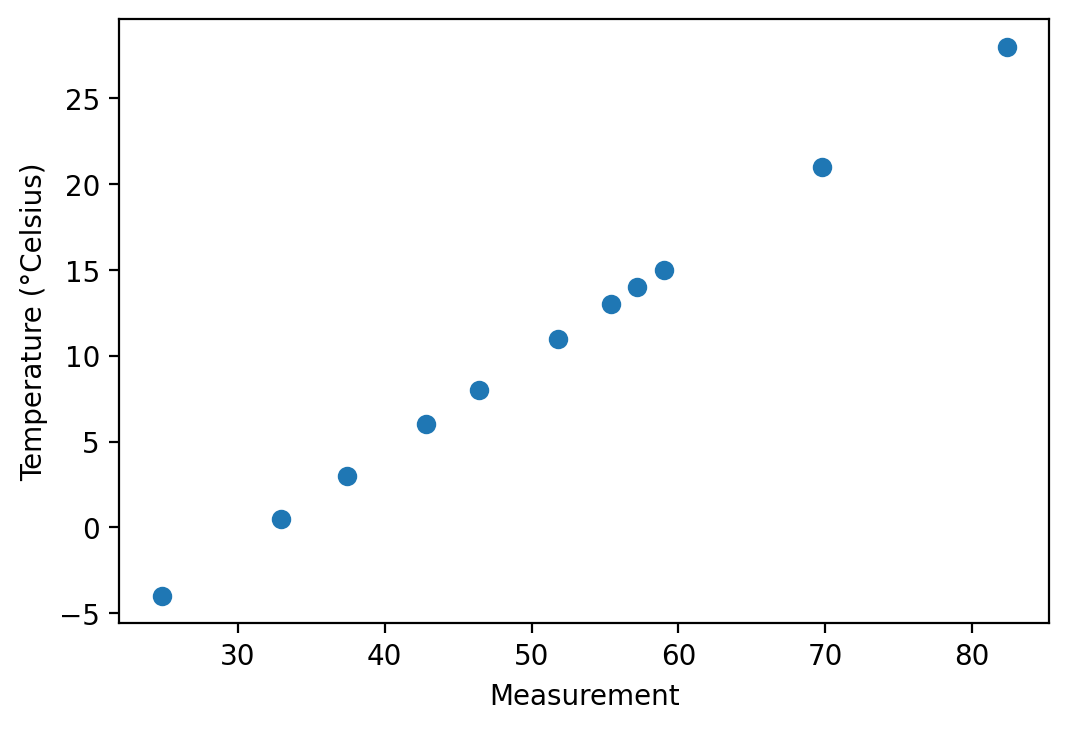

In [3]:
# Plot data
fig = plt.figure(dpi=200) # dpi: resolution of the figure
plt.xlabel("Measurement")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u, t_c, 'o')

In [4]:
# Define the model as a Python function
def model(t_u, w, b):
    return w * t_u + b

In [5]:
# Define the loss function
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean() # Mean squared loss

In [6]:
# Initialize the parameters and invoke the model
w = torch.ones(1)
b = torch.zeros(1)

t_p = model(t_u, w, b)
t_p

tensor([32.9000, 57.2000, 59.0000, 82.4000, 51.8000, 46.4000, 37.4000, 24.8000,
        42.8000, 55.4000, 69.8000])

In [7]:
# Check the value of the loss
loss = loss_fn(t_p, t_c)
loss

tensor(1681.5272)

In [8]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c)
    return dsq_diffs

In [9]:
def dmodel_dw(t_u, w, b):
    return t_u

In [10]:
def dmodel_db(t_u, w, b):
    return 1.0

In [11]:
# Define the gradient function 
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.mean(), dloss_db.mean()]) 

In [12]:
# The complete training loop
def training_loop(n_epochs, learning_rate, params, t_u, t_c, print_params=True):
    for epoch in range(1, n_epochs + 1):
        w, b = params

        t_p = model(t_u, w, b)  # Forward pass
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)  # Backward pass

        params = params - learning_rate * grad


        if epoch in {1, 2, 3, 10, 11, 99, 100, 4000, 5000, 10000, 100000}:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            print('    Params:', params)
            print('    Grad:  ', grad)
        if epoch in {4, 12, 101}:
            print('...')

    return params

In [13]:
# The model diverges instead of converging to a minimum with large learning rate
training_loop(n_epochs = 100, learning_rate = 1e-2, params = torch.tensor([0.0, 0.0]), t_u = t_u, t_c = t_c)

Epoch 1, Loss 187.386368
    Params: tensor([13.4659,  0.2100])
    Grad:   tensor([-1346.5909,   -21.0000])
Epoch 2, Loss 497449.718750
    Params: tensor([-738.3428,  -13.2925])
    Grad:   tensor([75180.8672,  1350.2495])
Epoch 3, Loss 1550619136.000000
    Params: tensor([41237.3320,   738.8163])
    Grad:   tensor([-4197567.5000,   -75210.8828])
...
Epoch 10, Loss 4435733517345685329666721257095168.000000
    Params: tensor([-6.9746e+16, -1.2497e+15])
    Grad:   tensor([7.0995e+18, 1.2721e+17])
Epoch 11, Loss 13827561903253331560802272988415131648.000000
    Params: tensor([3.8941e+18, 6.9777e+16])
    Grad:   tensor([-3.9639e+20, -7.1026e+18])
...
Epoch 99, Loss nan
    Params: tensor([nan, nan])
    Grad:   tensor([nan, nan])
Epoch 100, Loss nan
    Params: tensor([nan, nan])
    Grad:   tensor([nan, nan])


tensor([nan, nan])

In [14]:
# Try a smaller learning rate
training_loop(n_epochs = 100, learning_rate = 1e-4, params = torch.tensor([0.0, 0.0]), t_u = t_u, t_c = t_c)

Epoch 1, Loss 187.386368
    Params: tensor([0.1347, 0.0021])
    Grad:   tensor([-1346.5909,   -21.0000])
Epoch 2, Loss 57.551537
    Params: tensor([0.1928, 0.0028])
    Grad:   tensor([-581.3164,   -7.2875])
Epoch 3, Loss 33.357315
    Params: tensor([0.2179, 0.0030])
    Grad:   tensor([-250.9694,   -1.3682])
...
Epoch 10, Loss 27.809898
    Params: tensor([0.2369, 0.0011])
    Grad:   tensor([-0.7568,  3.1148])
Epoch 11, Loss 27.808882
    Params: tensor([0.2370, 0.0008])
    Grad:   tensor([-0.3585,  3.1219])
...
Epoch 99, Loss 27.722918
    Params: tensor([ 0.2375, -0.0267])
    Grad:   tensor([-0.0560,  3.1225])
Epoch 100, Loss 27.721943
    Params: tensor([ 0.2375, -0.0270])
    Grad:   tensor([-0.0559,  3.1224])


tensor([ 0.2375, -0.0270])

In [15]:
# Training the model 100000 epochs
params = training_loop(n_epochs = 100000, learning_rate = 1e-4, params = torch.tensor([0.0, 0.0]), t_u = t_u, t_c = t_c, print_params = False)
params

Epoch 1, Loss 187.386368
    Params: tensor([0.1347, 0.0021])
    Grad:   tensor([-1346.5909,   -21.0000])
Epoch 2, Loss 57.551537
    Params: tensor([0.1928, 0.0028])
    Grad:   tensor([-581.3164,   -7.2875])
Epoch 3, Loss 33.357315
    Params: tensor([0.2179, 0.0030])
    Grad:   tensor([-250.9694,   -1.3682])
...
Epoch 10, Loss 27.809898
    Params: tensor([0.2369, 0.0011])
    Grad:   tensor([-0.7568,  3.1148])
Epoch 11, Loss 27.808882
    Params: tensor([0.2370, 0.0008])
    Grad:   tensor([-0.3585,  3.1219])
...
Epoch 99, Loss 27.722918
    Params: tensor([ 0.2375, -0.0267])
    Grad:   tensor([-0.0560,  3.1225])
Epoch 100, Loss 27.721943
    Params: tensor([ 0.2375, -0.0270])
    Grad:   tensor([-0.0559,  3.1224])
...
Epoch 4000, Loss 24.167810
    Params: tensor([ 0.2586, -1.2039])
    Grad:   tensor([-0.0524,  2.9154])
Epoch 5000, Loss 23.332361
    Params: tensor([ 0.2638, -1.4929])
    Grad:   tensor([-0.0514,  2.8646])
Epoch 10000, Loss 19.568876
    Params: tensor([ 0.288

tensor([  0.5007, -14.7155])

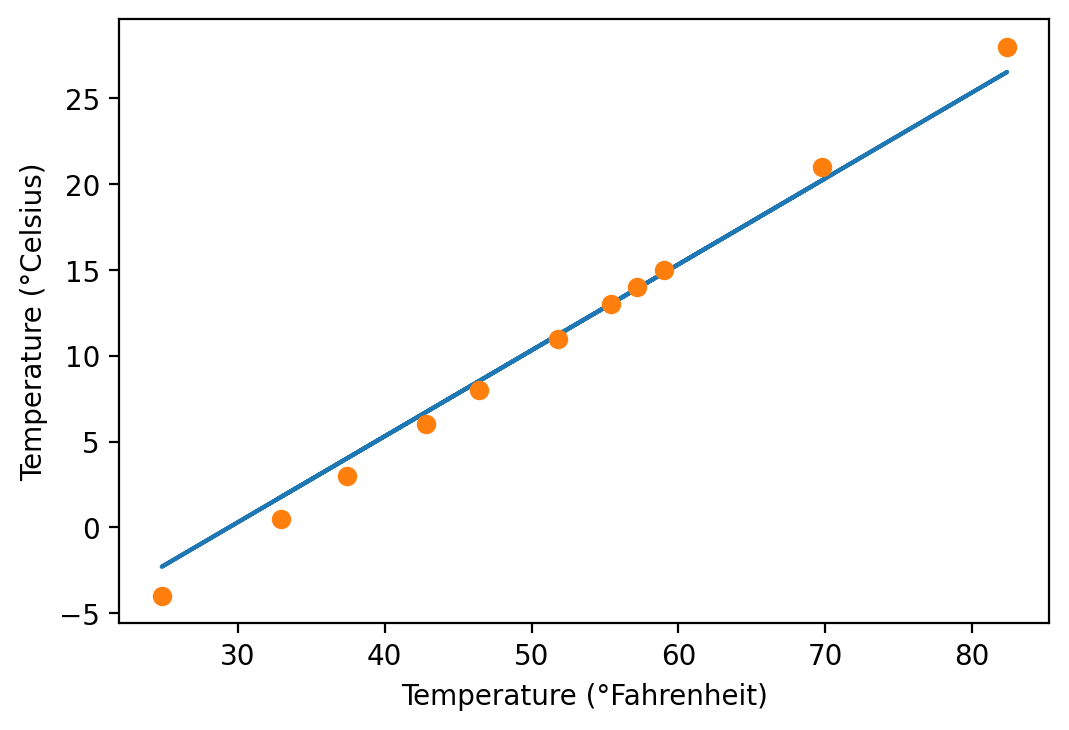

In [16]:
# Visualizing
from matplotlib import pyplot as plt

t_p = model(t_u, *params) #argument unpacking here: *params means to pass the elements of params as individual arguments. equivalent to model(t_un, params[0], params[1]).
fig = plt.figure(dpi=200)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u, t_p.detach())
plt.plot(t_u, t_c, 'o')

##PyTorch optimizer

In [17]:
import torch
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional',
 '_multi_tensor',
 'lr_scheduler',
 'swa_utils']

In [18]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [32.9, 57.2, 59.0, 82.4, 51.8, 46.4, 37.4, 24.8, 42.8, 55.4, 69.8]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [19]:
# Define model
def model(t_u, w, b):
    return w * t_u + b

In [20]:
# Define loss
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [21]:
# Define training loop
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params) 
        loss = loss_fn(t_p, t_c)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 5000 == 0:
            print('Epoch %d, Loss %f' % (epoch, float(loss)))
            
    return params

In [22]:
# Define a SGD optimizer
params = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 1e-4
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(n_epochs = 100000, optimizer = optimizer, params = params, t_u = t_u, t_c = t_c)

Epoch 5000, Loss 23.332361
Epoch 10000, Loss 19.568876
Epoch 15000, Loss 16.412432
Epoch 20000, Loss 13.765119
Epoch 25000, Loss 11.544819
Epoch 30000, Loss 9.682666
Epoch 35000, Loss 8.120876
Epoch 40000, Loss 6.810985
Epoch 45000, Loss 5.712368
Epoch 50000, Loss 4.791006
Epoch 55000, Loss 4.018200
Epoch 60000, Loss 3.370096
Epoch 65000, Loss 2.826465
Epoch 70000, Loss 2.370594
Epoch 75000, Loss 1.988215
Epoch 80000, Loss 1.667524
Epoch 85000, Loss 1.398525
Epoch 90000, Loss 1.172966
Epoch 95000, Loss 0.983774
Epoch 100000, Loss 0.825063


tensor([  0.5007, -14.7155], requires_grad=True)

In [23]:
# Using a Adam optimizer
params = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 1e-3
optimizer = optim.Adam([params], lr=learning_rate)

training_loop(n_epochs = 30000, optimizer = optimizer, params = params, t_u = t_u, t_c = t_c)

Epoch 5000, Loss 17.977310
Epoch 10000, Loss 8.228080
Epoch 15000, Loss 2.417738
Epoch 20000, Loss 0.171821
Epoch 25000, Loss 0.000000
Epoch 30000, Loss 0.000000


tensor([  0.5556, -17.7778], requires_grad=True)

## Training, testing, and overfitting

In [26]:
# Split the data into a training set and a testing set
torch.manual_seed(0)

n_samples = t_u.shape[0]
n_test = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_test]
test_indices = shuffled_indices[-n_test:]

train_indices, test_indices

(tensor([10,  0,  4,  3,  5,  8,  2,  1,  9]), tensor([7, 6]))

In [27]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

test_t_u = t_u[test_indices]
test_t_c = t_c[test_indices]

In [28]:
# Define training loop
def training_loop(n_epochs, optimizer, params, train_t_u, test_t_u, train_t_c, test_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)
                             
        test_t_p = model(test_t_u, *params)
        test_loss = loss_fn(test_t_p, test_t_c)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 5000 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"f" Testing loss {test_loss.item():.4f}")
            
    return params

In [31]:
# Model training and testing
params = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 1e-3
optimizer = optim.Adam([params], lr=learning_rate)

training_loop(n_epochs = 30000, optimizer = optimizer, params = params, train_t_u = train_t_u, test_t_u = test_t_u, train_t_c = train_t_c, test_t_c = test_t_c)

Epoch 1, Training loss 226.2500, Testing loss 12.5000
Epoch 2, Training loss 224.5845, Testing loss 12.4891
Epoch 3, Training loss 222.9259, Testing loss 12.4803
Epoch 5000, Training loss 13.3756, Testing loss 53.1700
Epoch 10000, Training loss 6.4599, Testing loss 25.6979
Epoch 15000, Training loss 2.1257, Testing loss 8.4567
Epoch 20000, Training loss 0.2359, Testing loss 0.9383
Epoch 25000, Training loss 0.0000, Testing loss 0.0000
Epoch 30000, Training loss 0.0000, Testing loss 0.0000


tensor([  0.5556, -17.7778], requires_grad=True)

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/DL_lab/Lab_5_Using_a_Neural_Network_to_Fit_the_Data_Solution.ipynb"